In [1]:
import numpy as np
import pandas as pd
from sklearn import datasets
#from sklearn import linear_model
#from sklearn.cluster import KMeans
#from sklearn import cross_validation
#from sklearn import metrics
#from pandas import DataFrame

In [2]:
# Загружаем набор данных Ирисы:
iris = datasets.load_iris()

In [3]:
pd.DataFrame(iris.data,columns = iris['feature_names'])

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [4]:
iris_frame = pd.DataFrame(iris.data,columns = iris.feature_names)
# Делаем имена колонок такие же, как имена переменных:
#iris_frame.columns = iris.feature_names
# Добавляем столбец с целевой переменной:
iris_frame['target'] = iris['target']
# Для наглядности добавляем столбец с сортами:
iris_frame['name'] = iris_frame['target'].map(lambda x : iris['target_names'][x])
# Смотрим, что получилось:
iris_frame.iloc[::10,::1]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,name
0,5.1,3.5,1.4,0.2,0,setosa
10,5.4,3.7,1.5,0.2,0,setosa
20,5.4,3.4,1.7,0.2,0,setosa
30,4.8,3.1,1.6,0.2,0,setosa
40,5.0,3.5,1.3,0.3,0,setosa
50,7.0,3.2,4.7,1.4,1,versicolor
60,5.0,2.0,3.5,1.0,1,versicolor
70,5.9,3.2,4.8,1.8,1,versicolor
80,5.5,2.4,3.8,1.1,1,versicolor
90,5.5,2.6,4.4,1.2,1,versicolor


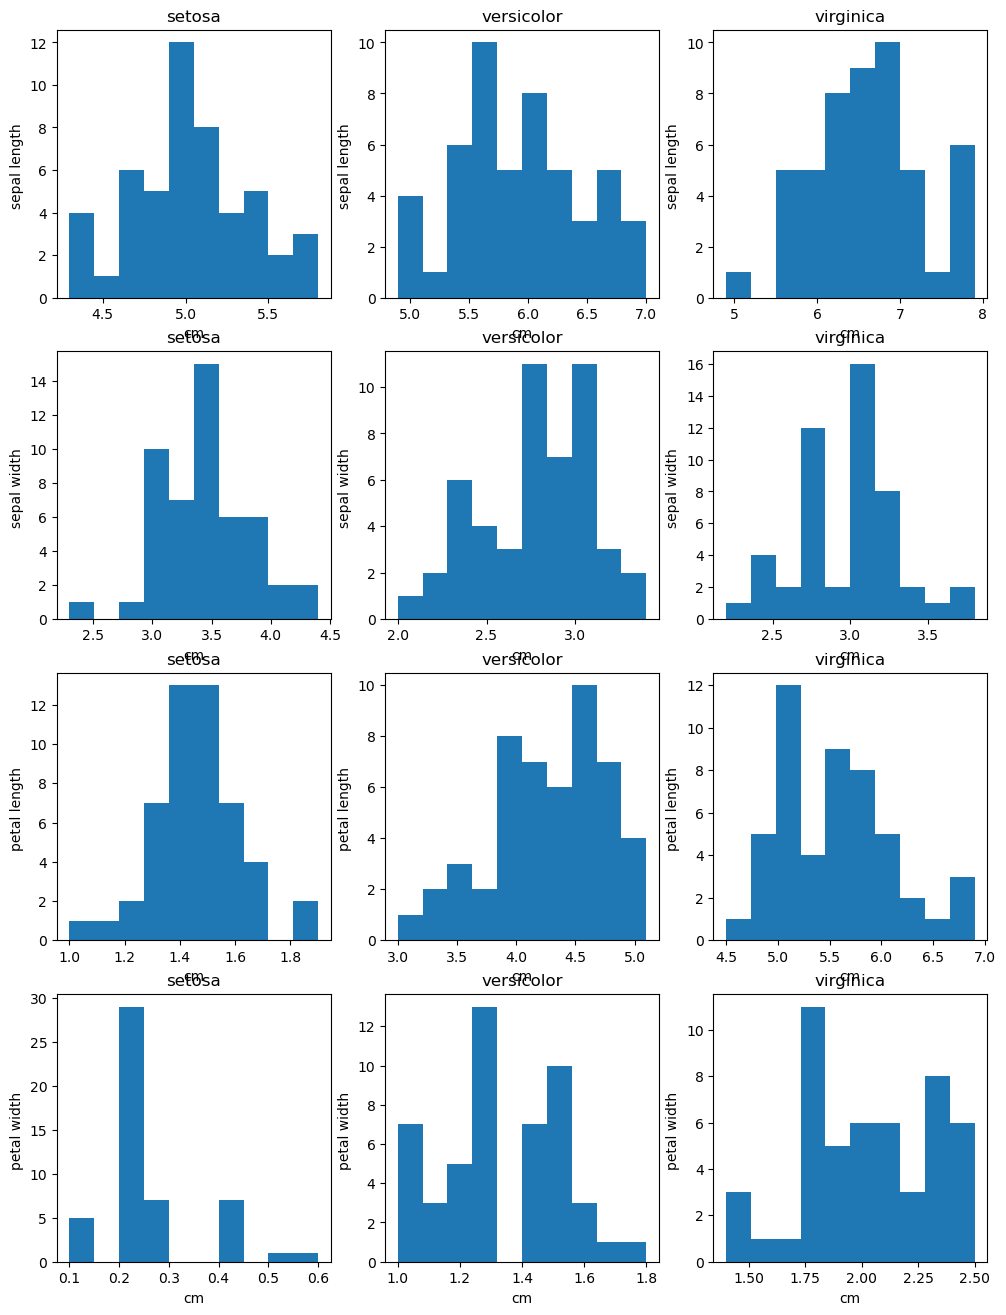

In [5]:
import matplotlib.pyplot as pyplot

pyplot.figure(figsize = (12, 16))
plot_number = 0
for feature_name in iris['feature_names']:
    for target_name in iris['target_names']:
        plot_number += 1
        pyplot.subplot(4, 3, plot_number)
        pyplot.hist(iris_frame.loc[iris_frame['name'] == target_name,feature_name])
        pyplot.title(target_name)
        pyplot.xlabel('cm')
        pyplot.ylabel(feature_name[:-4])

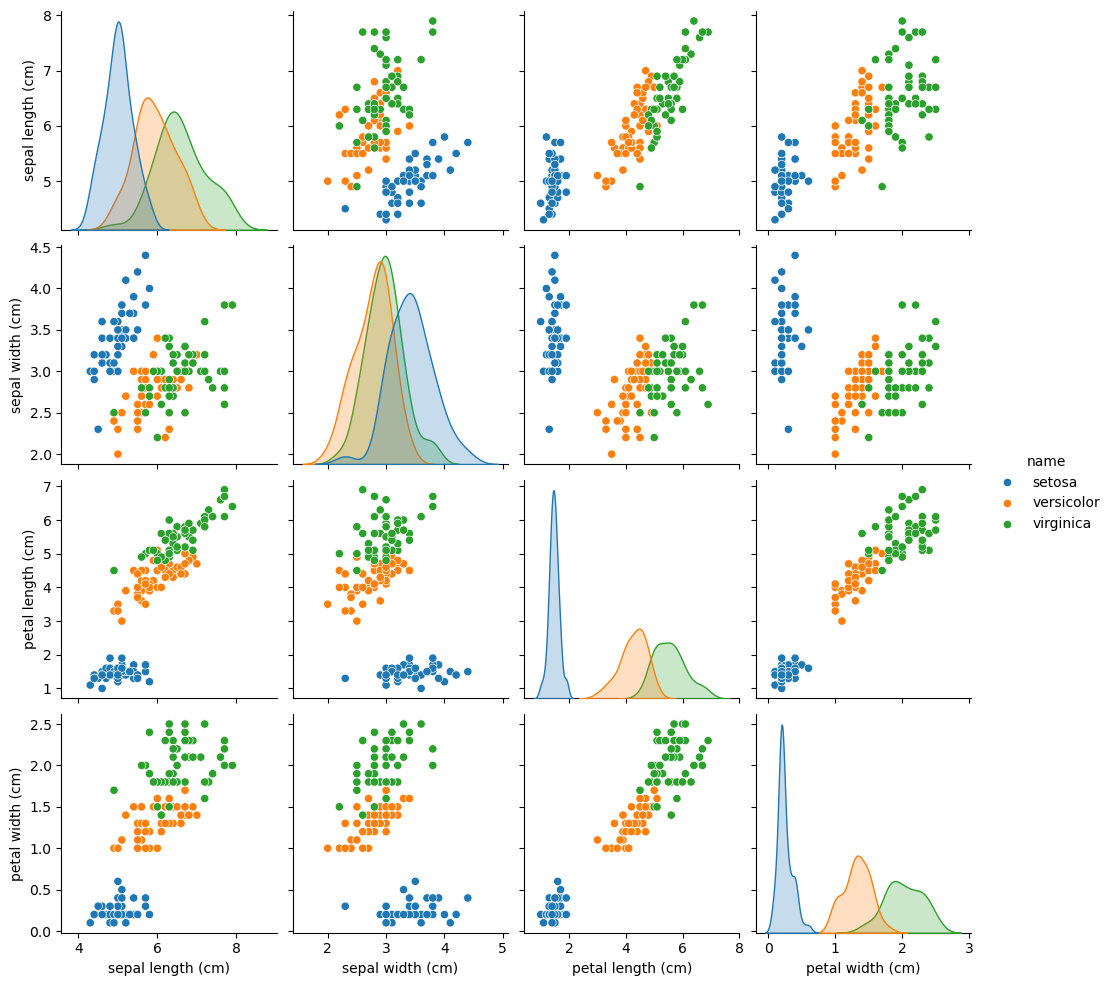

In [6]:
import seaborn as sns

sns.pairplot(iris_frame.iloc[:,[0,1,2,3,5]], hue = 'name')

In [7]:
# corr = cov(x,y)/BxBy - ковариация деленая на стандартаное отклонение
# Формула пирсона
iris_frame.iloc[:,:4].corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


In [8]:
#iris_frame[['sepal length (cm)','sepal width (cm)','petal length (cm)',
#            'petal width (cm)']].corr()
iris_frame.iloc[:,:4].cov()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),0.685694,-0.042434,1.274315,0.516271
sepal width (cm),-0.042434,0.189979,-0.329656,-0.121639
petal length (cm),1.274315,-0.329656,3.116278,1.295609
petal width (cm),0.516271,-0.121639,1.295609,0.581006


In [9]:
#iris_frame.groupby(['name','target']).corr()
iris_frame.iloc[:,[0,1,2,3,5]].groupby('name').corr()

sepal length (cm)  sepal width (cm)  \
name                                                                
setosa     sepal length (cm)           1.000000          0.742547   
           sepal width (cm)            0.742547          1.000000   
           petal length (cm)           0.267176          0.177700   
           petal width (cm)            0.278098          0.232752   
versicolor sepal length (cm)           1.000000          0.525911   
           sepal width (cm)            0.525911          1.000000   
           petal length (cm)           0.754049          0.560522   
           petal width (cm)            0.546461          0.663999   
virginica  sepal length (cm)           1.000000          0.457228   
           sepal width (cm)            0.457228          1.000000   
           petal length (cm)           0.864225          0.401045   
           petal width (cm)            0.281108          0.537728   

                              petal length (cm)  petal width (cm)  
name                                                               
setosa     sepal length (cm)           0.267176          0.278098  
           sepal width (cm)            0.177700          0.232752  
           petal length (cm)           1.000000          0.331630  
           petal width (cm)            0.331630          1.000000  
versicolor sepal length (cm)           0.754049          0.546461  
           sepal width (cm)            0.560522          0.663999  
           petal length (cm)           1.000000          0.786668  
           petal width (cm)            0.786668          1.000000  
virginica  sepal length (cm)           0.864225          0.281108  
           sepal width (cm)            0.401045          0.537728  
           petal length (cm)           1.000000          0.322108  
           petal width (cm)            0.322108          1.000000

In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

models = [
    # 
    ('LDA',LinearDiscriminantAnalysis()),
    #
    ('QDA', QuadraticDiscriminantAnalysis()),
    #
    ('LR', LogisticRegression()),
    #
    ('SVM with Linear Kernel', SVC(kernel='linear')),
    #
    ('SVM with RBF Kernel', SVC(kernel='rbf'))
]

x_min = iris_frame['petal width (cm)'].min()
x_max = iris_frame['petal width (cm)'].max()
y_min = iris_frame['petal length (cm)'].min()
y_max = iris_frame['petal length (cm)'].max()

xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300), 
        np.linspace(y_min, y_max, 300)
    )

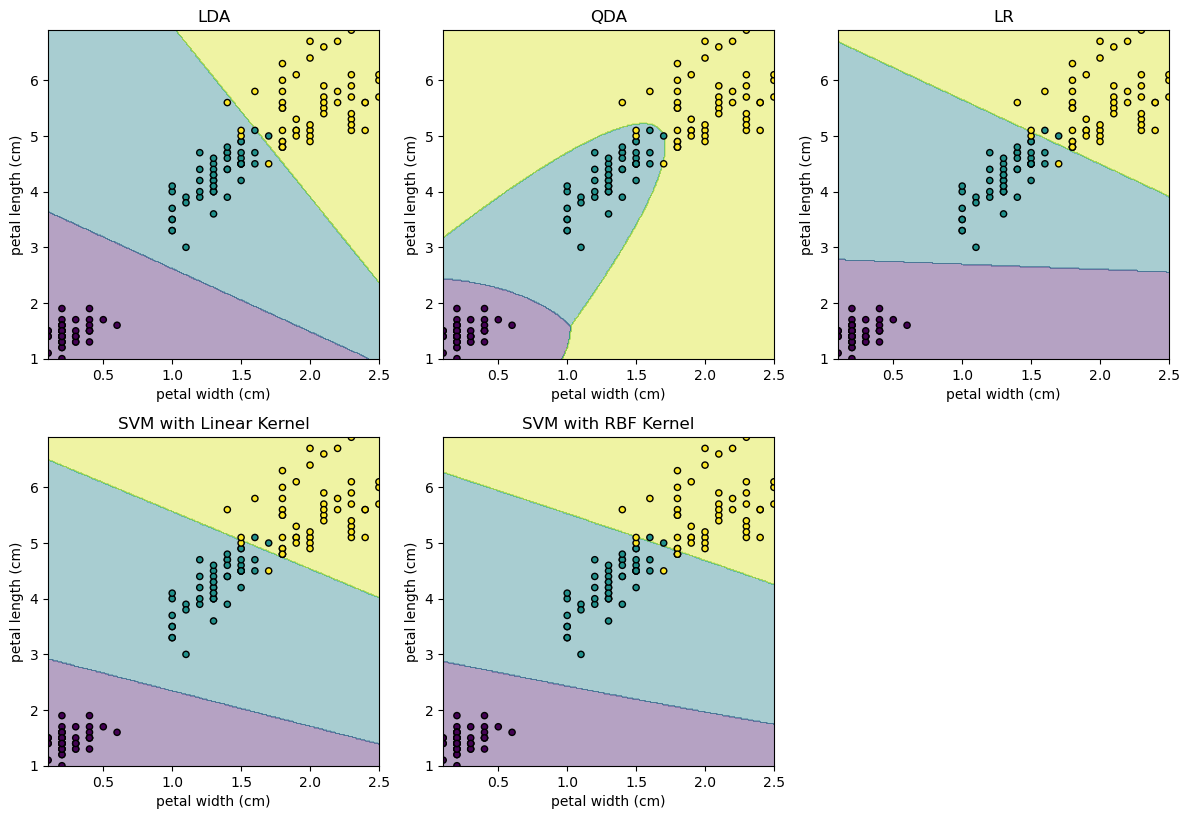

In [11]:
X = iris_frame[['petal width (cm)', 'petal length (cm)']].to_numpy()
y = iris_frame['target'].to_numpy()

pyplot.figure(figsize = (12, 16))
plot_number = 0
for (name, model) in models:
    model.fit(X,y)
    plot_number += 1
    pyplot.subplot(4, 3, plot_number)
    predicted = model.predict(np.c_[xx.ravel(), yy.ravel()])
    predicted = predicted.reshape(xx.shape)
    pyplot.contourf(xx, yy, predicted, alpha=0.4)
    pyplot.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=20)
    
    pyplot.xlabel('petal width (cm)')
    pyplot.ylabel('petal length (cm)')
    pyplot.title(f'{name}')
    pyplot.tight_layout()

pyplot.show()

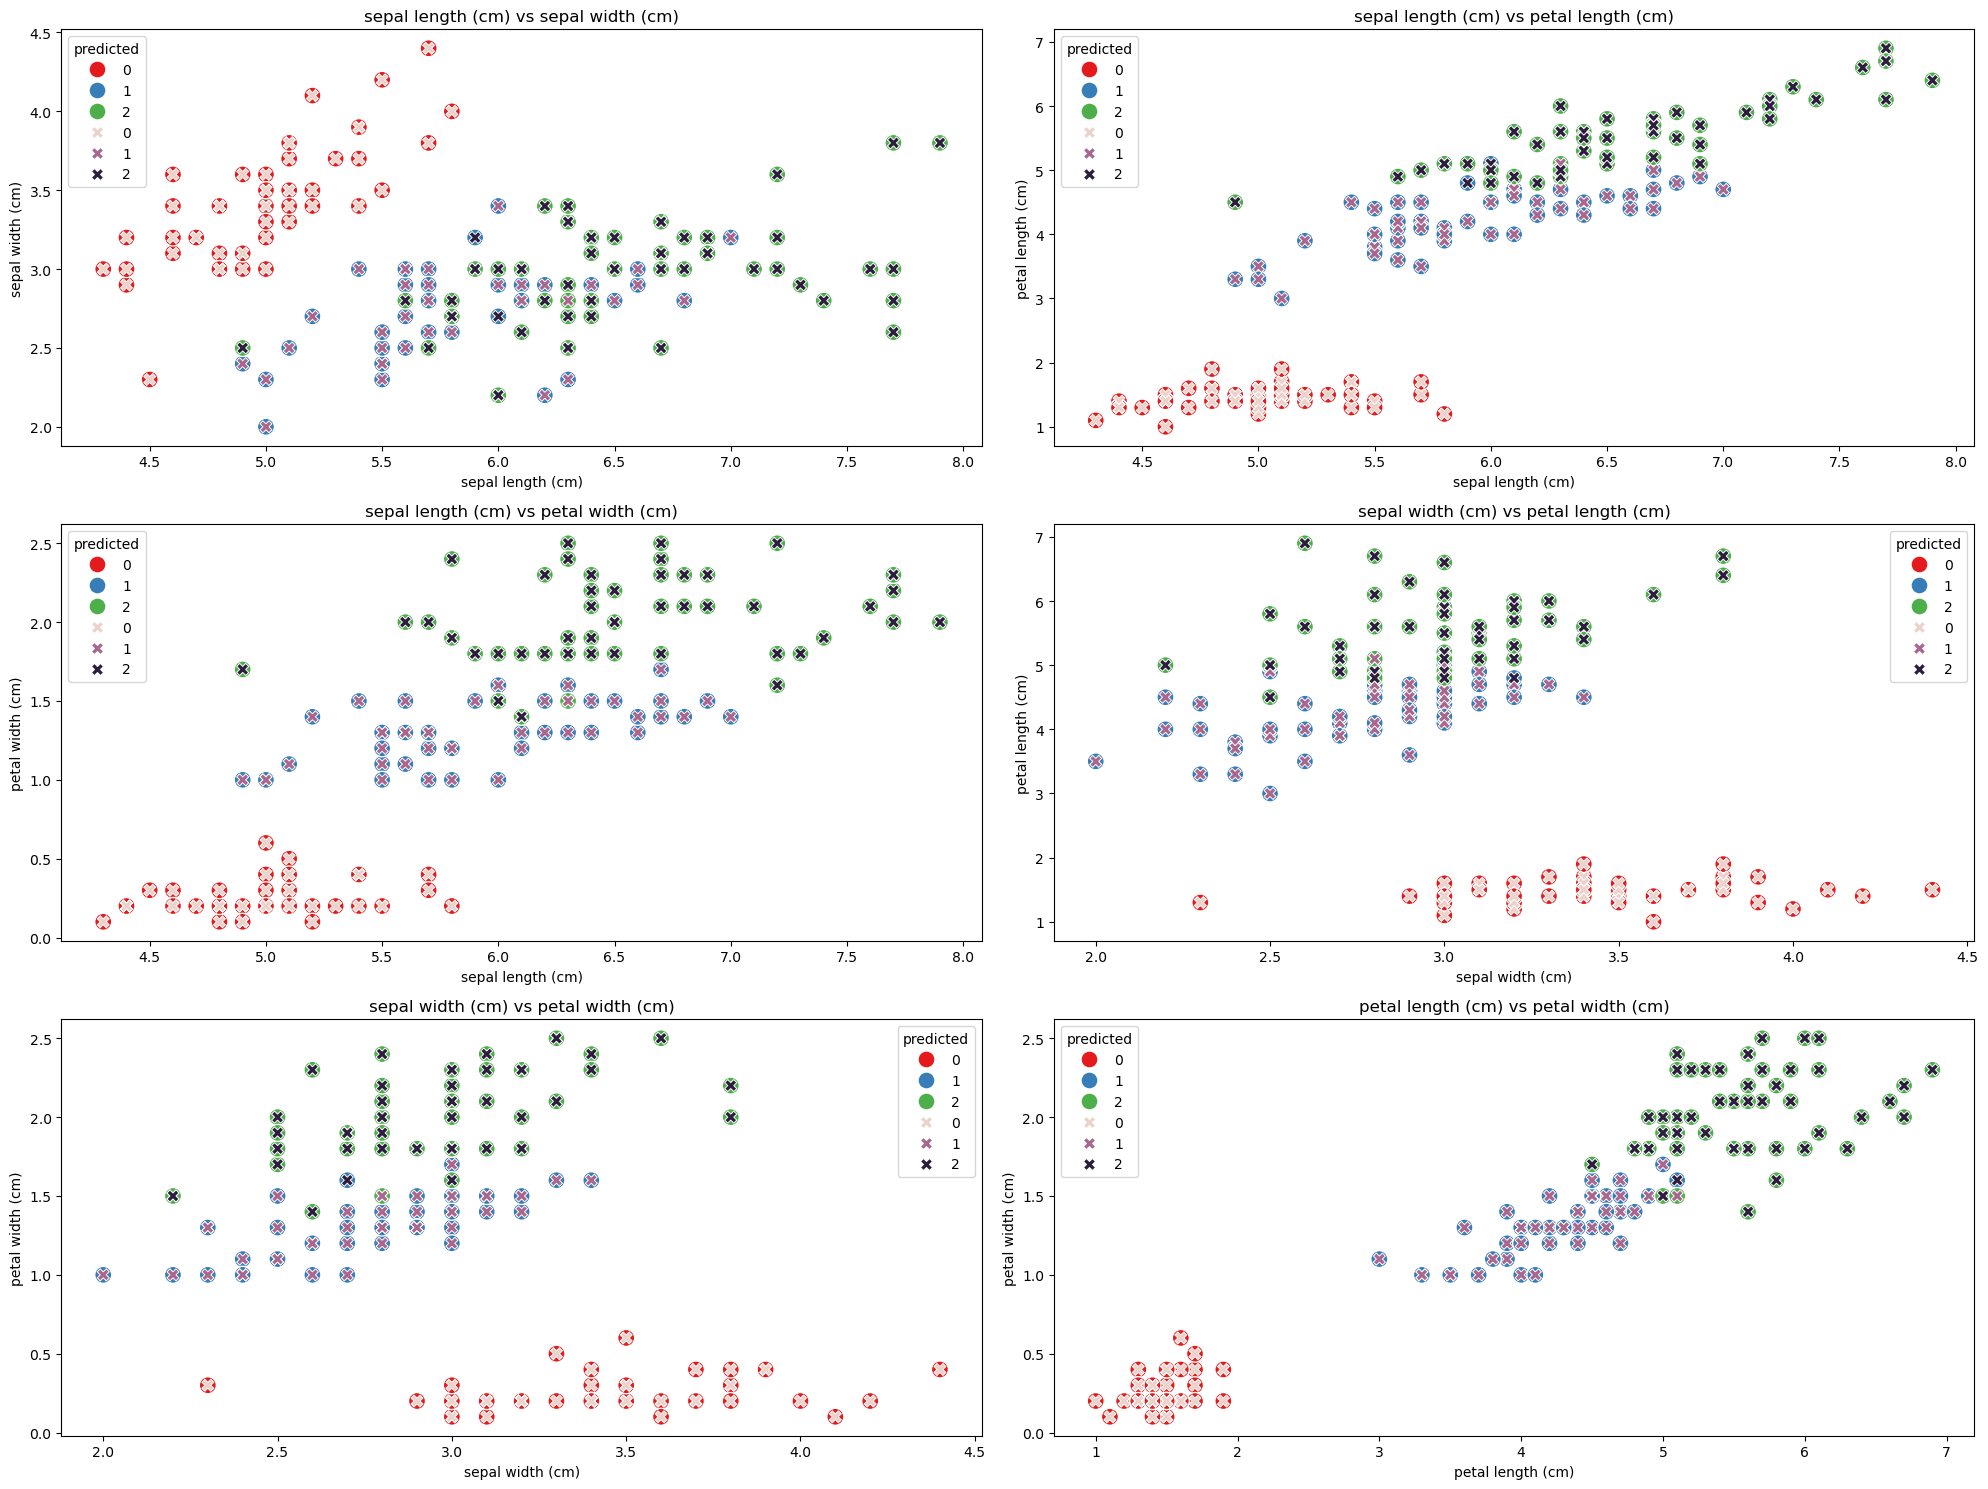

In [12]:
from itertools import combinations

X = iris_frame[iris.feature_names].values
y = iris_frame['target'].values

lda_full = LinearDiscriminantAnalysis().fit(X, y)
iris_frame['predicted'] = lda_full.predict(X)

features = iris.feature_names
fig, axes = pyplot.subplots(3, 2, figsize=(20, 15))

for ax, (f1, f2) in zip(axes.flat, combinations(features, 2)):
    sns.scatterplot(data=iris_frame, x=f1, y=f2, hue='target', 
                   palette='Set1', ax=ax, s=150)
    sns.scatterplot(data=iris_frame, x=f1, y=f2, hue='predicted',
                   color='black', marker='X', s=75, ax=ax)
    ax.set_title(f'{f1} vs {f2}')

pyplot.tight_layout()
pyplot.show()

In [13]:
class QuadraticDiscriminant:
    def __init__(self):
        self.means_ = {}
        self.covariances_ = {}
        self.priors_ = {}
        self.cov_inverces_ = {}
        self.determiners_ = {}
        
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        
        for class_label in self.classes_:
            X_class = X[y == class_label]
            self.means_[class_label] = np.mean(X_class, axis=0)
            self.covariances_[class_label] = np.cov(X_class.T)
            self.priors_[class_label] = len(X_class) / len(X)
            self.cov_inverces_[class_label] = np.linalg.inv(self.covariances_[class_label])
            self.determiners_[class_label] = np.linalg.det(self.covariances_[class_label])
            
        return self
    
    def predict(self, X):
        predictions = []
        for x in X:
            scores = []
            for class_label in self.classes_:
                diff = x - self.means_[class_label]
                cov_inv = self.cov_inverces_[class_label]
                term1 = -0.5 * np.log(self.determiners_[class_label])
                term2 = -0.5 * diff @ cov_inv @ diff.T
                term3 = np.log(self.priors_[class_label])
                score = term1 + term2 + term3
                scores.append(score)
            predictions.append(self.classes_[np.argmax(scores)])
        
        return np.array(predictions)

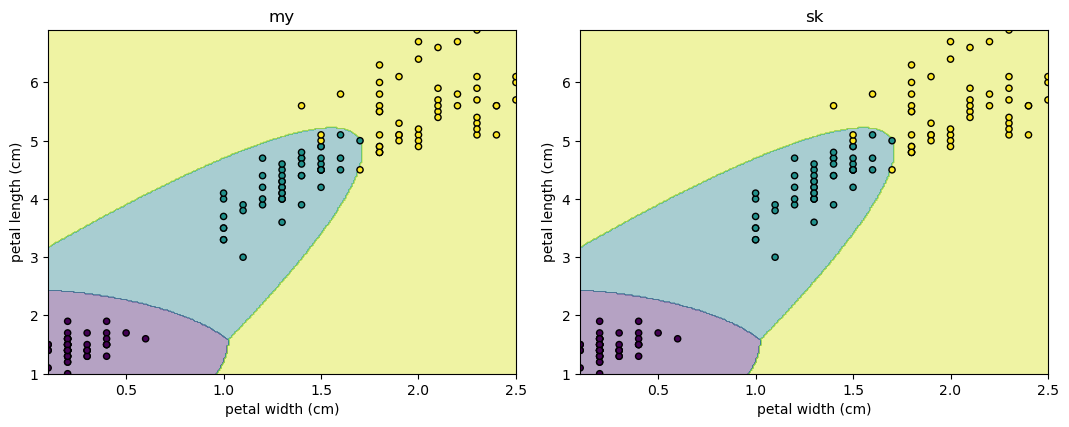

In [14]:
X = iris_frame[['petal width (cm)', 'petal length (cm)']].to_numpy()
y = iris_frame['target'].to_numpy()

cmp = [
    ('my', QuadraticDiscriminant()),
    ('sk', QuadraticDiscriminantAnalysis())
]

pyplot.figure(figsize = (16, 16))
plot_number = 0
for (name, model) in cmp:
    model.fit(X,y)
    plot_number += 1
    pyplot.subplot(4, 3, plot_number)
    predicted = model.predict(np.c_[xx.ravel(), yy.ravel()])
    predicted = predicted.reshape(xx.shape)
    pyplot.contourf(xx, yy, predicted, alpha=0.4)
    pyplot.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=20)
    
    pyplot.xlabel('petal width (cm)')
    pyplot.ylabel('petal length (cm)')
    pyplot.title(f'{name}')
    pyplot.tight_layout()

pyplot.show()